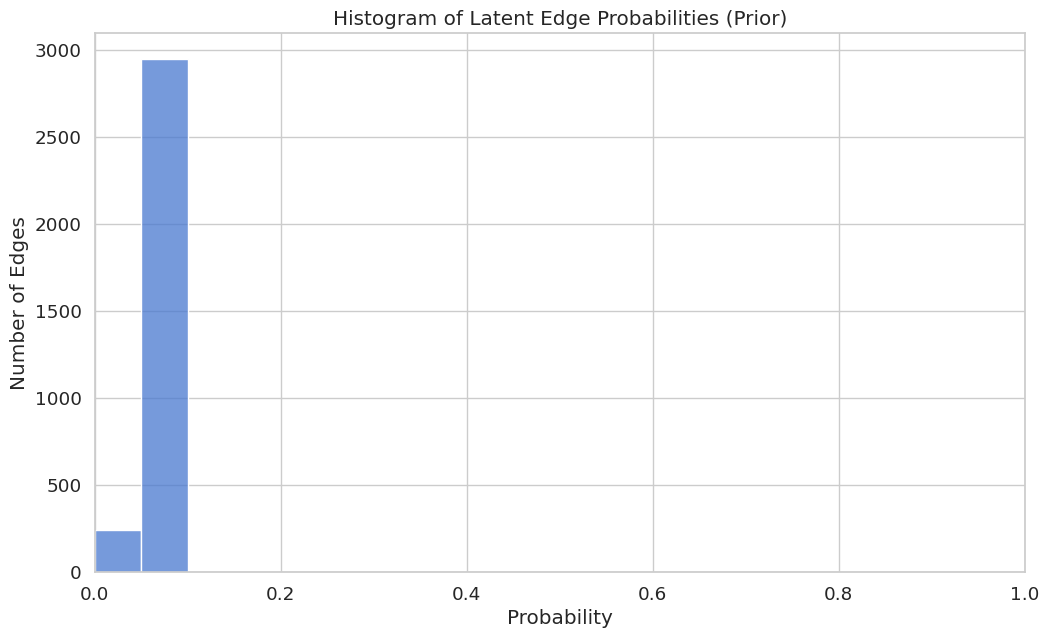

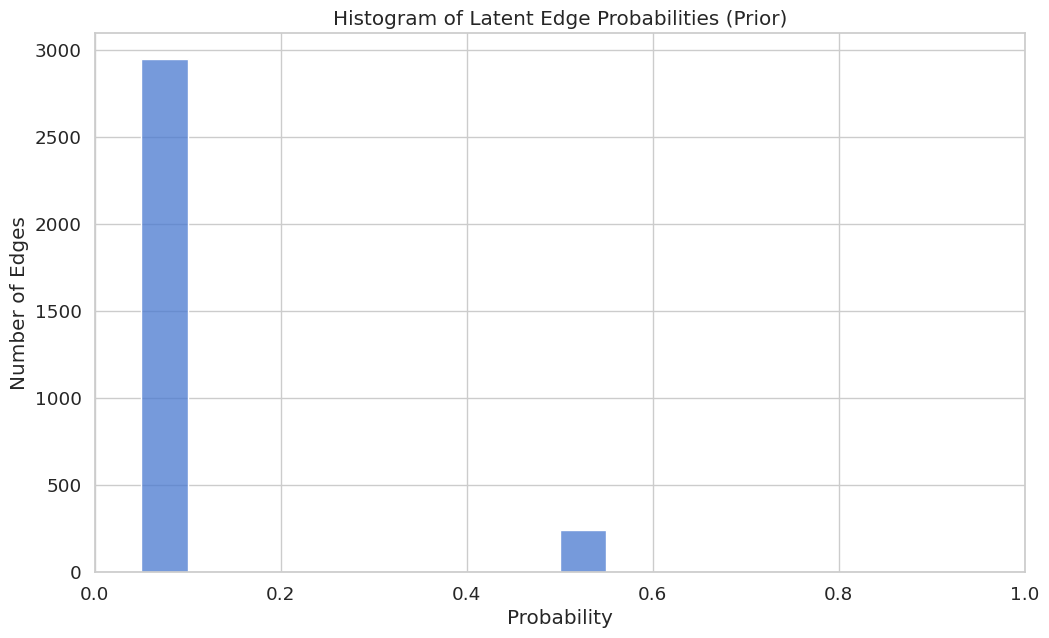

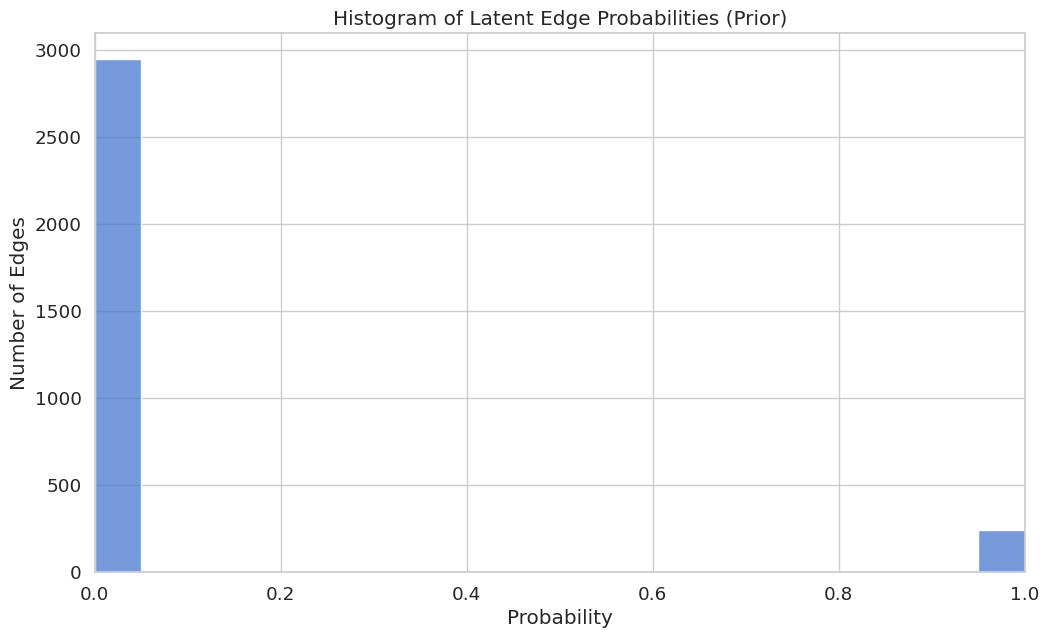

In [3]:
import grid2op
import torch

from rarl import fully_connected_edge_index
from src.visualization.utils import visualize_prior
from grid2op_env.observation_converter import GraphObservationConverter, EDGE_INDEX
from rarl.prior import get_prior_tensor, get_priors

def prior_from_env(env_name: str, p: float):
    env = grid2op.make(env_name)
    obs_space = GraphObservationConverter(env.observation_space)
    obs_g2op = env.reset()
    obs_gym = obs_space.to_gym(obs_g2op)
    graph_edges = torch.from_numpy(obs_gym[EDGE_INDEX])
    all_edges = fully_connected_edge_index(obs_space.num_nodes, self_loops=False)
    p_graph, p_non_graph = get_priors(
        prob_graph_edges_exist=p,
        num_graph_edges=graph_edges.shape[-1],
        num_non_graph_edges=all_edges.shape[-1] - graph_edges.shape[-1],
    )
    return get_prior_tensor(graph_edges, all_edges, p_graph, p_non_graph, return_mask=False)

for p in [0.0, 0.5, 1.0]:
    _ = visualize_prior(prior_from_env("l2rpn_case14_sandbox", p))